# Library

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import sys

import os
sys.path.append('../../')   
import Modules_utility_analysis as util

import geopandas as gpd
from shapely.geometry import Point

import seaborn as sns

from scipy.stats import linregress,gaussian_kde,rankdata,median_abs_deviation,linregress
from scipy.stats import pearsonr, combine_pvalues,ttest_ind

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm,TwoSlopeNorm,to_rgba
from matplotlib.collections import LineCollection
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse, Polygon
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.lines as mlines

import scipy.stats as stats
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.crs import PlateCarree
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.feature import ShapelyFeature, OCEAN, LAKES
from cartopy.mpl.patch import geos_to_path
from cartopy.io.shapereader import Reader as ShapeReader, natural_earth
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

import geocat.viz as gv

import cmaps
import ast
import string

import multiprocessing

import pymannkendall as mk
from sklearn.linear_model import TheilSenRegressor
tzs={'ISONE':'Etc/GMT+5','ERCOT':'Etc/GMT+6'}

In [12]:
#colors for different things
colorpalattes={"line":"black","Line":"black",
"wind":'forestgreen',"solar":"salmon",
"wind-onshore":'forestgreen',"solar-UPV":"salmon",
"strg":"purple","sDis":"purple","storage":"purple","Storage":"purple",
'demand':'black','NL':'black',
'rcp85': 'orangered','rcp45': 'mediumseagreen',
'historic':'dimgrey', 'rcp85hotter': 'orangered','rcp45hotter': 'mediumseagreen',
'rcp85hotter_oos':'coral',
1:'tab:blue',8:'tab:red',
'DJF': 'tab:blue', 'MAM': 'tab:green','JJA': 'tab:red', 'SON': 'tab:orange', 
1: 'tab:blue', 2:'tab:green', 3: 'tab:red', 4: 'tab:orange'}

ISO_palettes={'ISONE':'tab:blue','ERCOT':'tab:orange'}

scenario_labels={"historic":"HIST","rcp85hotter":"SSP585","rcp45hotter":"SSP245"}
linestyles={'historic':'-','rcp85hotter':'dotted','rcp45hotter':'-.'}
seasonsnames={1:'Winter',2:'Spring',3:'Summer',4:'Fall'}
techs_RE=["wind-onshore","solar-UPV"]
techs_all = ["wind-onshore", "solar-UPV", 'strg','line']

tech_names={"line":"Transmission","wind":"Wind","wind-onshore":"Wind","solar-UPV":"Solar","solar":"Solar","strg":"Storage",'total':'Total','trans':'Trans.','demand':'Demand','NL':'Net load',
'Storage':'Storage'}



##Font sizes#####
plt.rcParams['axes.labelpad'] = 3
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlepad'] = 3
plt.rcParams['axes.titlesize'] = 11

plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['xtick.major.pad'] = 2.5
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.pad'] = 2.5
plt.rcParams['ytick.major.size'] = 4

plt.rcParams['xtick.minor.pad'] = 0
plt.rcParams['xtick.minor.size'] = 1
plt.rcParams['ytick.minor.pad'] = 0
plt.rcParams['ytick.minor.size'] = 1

plt.rcParams['savefig.directory'] ="./figures/"
plt.rcParams['savefig.format'] = 'pdf'
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.dpi'] = 100

plt.rcParams['legend.title_fontsize'] = 9
plt.rcParams['legend.fontsize'] = 10

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'sans-serif'


In [4]:
def scale_sizes(data, smin, smax, vmin=None, vmax=None, transform="sqrt"):
    # Convert to numpy array for vector operations
    data = np.asarray(data, dtype=float)
    
    # Set input bounds
    if vmin is None: vmin = np.min(data)
    if vmax is None: vmax = np.max(data)
    
    # Avoid division by zero if all values are the same
    if vmax == vmin:
        return np.full_like(data, (smin + smax) / 2)

    # 1. Normalize the data to [0, 1] range
    # Clip ensures values outside [vmin, vmax] don't break the scale
    norm_data = np.clip((data - vmin) / (vmax - vmin), 0, 1)
    
    # 2. Apply transformation
    if transform == "sqrt":
        # Best for marker area: area ~ value
        transformed_data = np.sqrt(norm_data)
    elif transform == "linear":
        # Best for alpha/opacity
        transformed_data = norm_data
    else:
        raise ValueError("Transform must be 'linear' or 'sqrt'")
    
    # 3. Rescale to [smin, smax]
    scaled_data = smin + (transformed_data * (smax - smin))
    
    return scaled_data

## paths and library

In [ ]:
mdir="./"
metdir="../data/"
ISOs=['ISONE','ERCOT']
ny_test=10
inv_ny=2

np.random.seed(42)  # Set seed for reproducible results
hist_years = np.random.choice(list(range(2001, 2020)), size=10, replace=False) # Historical period: 2001-2020

sces=['historic','rcp85hotter']
rps=1
dailyhh = 3
hourlyhh = 1
seid=0
eeid=44

In [ ]:
def get_ensemble_slopes(df,var):
    """Calculates linear slope for each ens_id."""
    slopes = []
    for eid, group in df.groupby('id'):
        slope, _, _, _, _ = linregress(group['Year'], group[var])
        slopes.append(slope)
    return np.array(slopes)

In [8]:
def get_df(df, rps=None, ensid=None, scenario=None,ny=None):
    df = df.reset_index(drop=True)
    df = df.set_index(['RPS','ensid','ny','inv_sce'])
    if rps is not None:
        dfa = df.iloc[df.index.get_level_values('RPS') == rps]
    else:
        dfa = df
    if ensid is not None:
        dfa = dfa.iloc[dfa.index.get_level_values('ensid') == ensid]
    if scenario is not None:
        dfa = dfa.iloc[dfa.index.get_level_values('inv_sce') == scenario]
    if ny is not None:
        dfa = dfa.iloc[dfa.index.get_level_values('ny') == ny]
    return dfa

In [9]:
def get_LL(x, threshold=1, exceed=True, lag=False):
    if isinstance(x, pd.Series):
        df = pd.DataFrame({'x': x})
    elif isinstance(x, pd.DataFrame):
        df = x.copy()
    else:
        raise ValueError("Input 'x' should be a pandas Series or DataFrame.")
    df = df.reset_index(drop=True)
    # Detect threshold exceedance
    df['occ'] = (df['x'] > threshold).astype(int) if exceed else (df['x'] < threshold).astype(int)
    # Apply lag if required
    if lag:
        df['occ'] = (df['occ'] | ((df['occ'].shift(1) == 1) & (df['x'].shift(1) * df['x'] > 0))).astype(int)
    # Identify event groups
    df['event_group'] = (df['occ'].diff() == 1).cumsum()
    df.loc[df['occ'] == 0, 'event_group'] = None  # Remove non-event indices
    # Compute duration and magnitude for each event
    event_stats = df.groupby('event_group').agg(
        dur=('occ', 'sum'),
        mag=('x', lambda s: abs(s).sum())
    ).dropna()
    # Ensure proper data type for assignments
    df[['dur', 'mag']] = 0.0  # Explicitly initialize as float
    first_occurrences = df.groupby('event_group').head(1).index  # Get first indices of events
    # Map event stats to first occurrences and convert to float
    df.loc[first_occurrences, 'dur'] = df.loc[first_occurrences, 'event_group'].map(event_stats['dur'].astype(float))
    df.loc[first_occurrences, 'mag'] = df.loc[first_occurrences, 'event_group'].map(event_stats['mag'].astype(float))
    return df

In [10]:
def maps_frame(ISO,nfig,names=None):
    if nfig<=3:
        fig,axsd=plt.subplots(1,nfig,figsize=(10,10),subplot_kw={'projection': ccrs.PlateCarree()})
    elif nfig==4:
        fig,axsd=plt.subplots(2,2,figsize=(4,8),subplot_kw={'projection': ccrs.PlateCarree()})
    elif (nfig>4) and (nfig<=6):
        fig,axsd=plt.subplots(2,3,figsize=(15,10),subplot_kw={'projection': ccrs.PlateCarree()})
    else:
        fig,axsd=plt.subplots(3,3,figsize=(15,10),subplot_kw={'projection': ccrs.PlateCarree()})
    axs=axsd.flatten()
    try:
        counties = gpd.read_file(f'./ISO_county/{ISO}/{ISO}.shp')
        has_boundaries = True
    except:
        print("Could not load county boundaries shapefile")
        has_boundaries = False

    for ic in range(nfig):
        util.setupmapbg(axs[ic], ISO)
        axs[ic].set_aspect('equal')
        if has_boundaries:
            counties.boundary.plot(
                ax=axs[ic], color='black', linewidth=0.5, alpha=0.2)
        # counties.plot(ax=axs[ic], color='lightgray', alpha=0.2, edgecolor='gray', linewidth=0.5)
        if names is not None:
            util.setsubtitle(ax=axs[ic],title=names[ic])
        else:
            util.setsubtitle(ax=axs[ic],title='')
    return fig,axs

In [11]:
def parse_timestamp(ts):
    ts_str = str(ts)  # Convert to string
    date_part, frac_part = ts_str.split('.') if '.' in ts_str else (ts_str, '0')  # Split into date and fraction
    dt = pd.to_datetime(date_part, format="%Y%m%d")  # Convert date
    frac_seconds = float(f"0.{frac_part}") * 86400  # Convert fraction of a day to seconds
    dt = dt + pd.to_timedelta(frac_seconds, unit='s')  # Add fractional time
    return dt.round('h')

# fig1-schematic

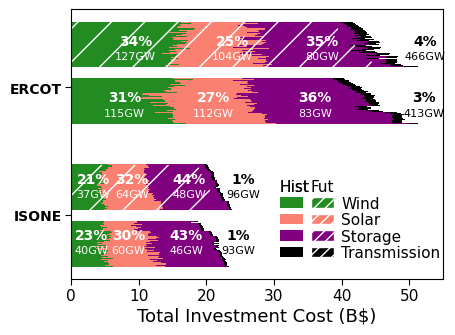

In [ ]:
sces=['historic','rcp85hotter']
fig,ax_bar = plt.subplots(1,1,figsize=(4.8,3.5),frameon=False)
nsce=len(sces)
cap_columns=['strg','line','wind-new','solar-UPV']

for ir in range(2):
    ISO=ISOs[ir]
    sdata=pd.read_csv('%s/%s_investment_summary.csv'%(mdir,ISO))
    n_eid=eeid-seid+1

    for irr in range(nsce):
        sce=sces[irr]
        cp_data=get_df(sdata,ny=inv_ny,scenario=sce,rps=rps)  
        cp_data=cp_data.sort_values('total system cost',ascending=False)
        cu1=np.zeros(n_eid)
        total_est_cost=cp_data['wind-onshore_est_cost']+cp_data['solar-UPV_est_cost']+cp_data['storage_est_cost']+cp_data['Line_est_cost']
        total_est_cost=total_est_cost/(10**9) # Convert to billions
        for tech in ['wind-onshore','solar-UPV','storage','Line']:
            toplot=cp_data[f'{tech}_est_cost']/(10**9)
            p = ax_bar.barh(np.arange((n_eid*nsce+50*(nsce-1))*ir+(n_eid+10)*irr,(n_eid*nsce+50*(nsce-1))*ir+(n_eid+10)*irr+n_eid,1),toplot, 1,
                                color=colorpalattes[tech],left=cu1)
            meanr=toplot/total_est_cost*100
            meanr=meanr.mean()
            cap=cp_data[f'{tech}_total_cap'].mean()/1000
            cap=int(cap)
            x=cu1[int(n_eid/2+1)]+toplot.values[int(n_eid/2+1)]*0.5
            
            if tech!='Line':
                ax_bar.text(x+1.08,(n_eid*nsce+45*(nsce-1))*ir+(n_eid+10)*irr+n_eid/3*2,"%d"%(meanr)+"%",ha='center',va='center',color='white',fontsize=10,fontweight='bold')
                ax_bar.text(x+1.08,(n_eid*nsce+45*(nsce-1))*ir+(n_eid+10)*irr+n_eid/3,"%d"%(cap)+"GW",ha='center',va='center',color='white',fontsize=8)
            else:
                ax_bar.text(x*1.18,(n_eid*nsce+45*(nsce-1))*ir+(n_eid+10)*irr+n_eid/3*2,"%d"%(meanr)+"%",ha='center',va='center',color='black',fontsize=10,fontweight='bold')
                ax_bar.text(x*1.18,(n_eid*nsce+45*(nsce-1))*ir+(n_eid+10)*irr+n_eid/3,"%d"%(cap)+"GW",ha='center',va='center',color='black',fontsize=8)
            cu1+=toplot.values
    ymin=np.arange((n_eid*nsce+50*(nsce-1))*ir+(n_eid+10)*irr,(n_eid*nsce+50*(nsce-1))*ir+(n_eid+10)*irr+n_eid,1).min()
    ymax=np.arange((n_eid*nsce+50*(nsce-1))*ir+(n_eid+10)*irr,(n_eid*nsce+50*(nsce-1))*ir+(n_eid+10)*irr+n_eid,1).max()
    ax_bar.add_patch(Polygon([(0, ymin), (0, ymax), (cu1.mean()*0.85, ymax), (cu1.mean(), ymin)],linewidth=0,
                                hatch='/', facecolor='none', edgecolor='white', zorder=2,alpha=1))
               
ax_bar.set_ylabel('')
ax_bar.set_yticks([50,175])
ax_bar.set_yticklabels(ISOs,fontsize=10,fontweight='bold')

ax_bar.set_xlim([0,55])
ax_bar.tick_params(axis='x', which='major', labelsize=11)
ax_bar.set_xlabel('Total Investment Cost (B$)',fontsize=13)

colors = {key:colorpalattes[key] for key in techs_all}
legend_patched = [mpatches.Patch(facecolor=colors[key], hatch='///',edgecolor='white', label=tech_names[key]) for key in colors.keys()]
legend_solid = [mpatches.Patch(facecolor=colors[key], label='') for key in colors.keys()]
lg_patched = ax_bar.legend(handles=legend_patched,loc='upper right', title="Fut", labelspacing=0.1,fontsize=11,title_fontsize=11,
                          frameon=False,handlelength=1.5,alignment='left',handletextpad=0.5,bbox_to_anchor=(1.03, 0.42))
lg_solid = ax_bar.legend(handles=legend_solid, loc='upper right',title="Hist", labelspacing=0.1,fontsize=11,title_fontsize=11,
                          frameon=False, handlelength=1.5,alignment='left',handletextpad=0.5,bbox_to_anchor=(0.68, 0.42))
ax_bar.add_artist(lg_patched)
ax_bar.add_artist(lg_solid)

plt.savefig(f'figures/cost.pdf',bbox_inches='tight',dpi=300)
plt.show()

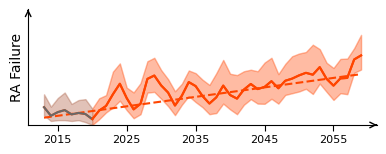

In [ ]:

fig, axs = plt.subplots(1, 1, figsize=(4.5, 1.5))
var='occ'
vars=['Occ','DurMax','MaxMagEvent']
vars_labels={'Occ':'Occurence','DurMax':'Duration','MaxMagEvent':'Severity'}
vars_labels_units={'Occ':'[-]','DurMax':'[hrs]','MaxMagEvent':'[GW]'}
sce='rcp85hotter'
ISO='ISONE'


hist=pd.read_csv('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_heatmap.csv'%(inv_ny,ISO,rps,'historic'))
hist =hist.groupby(['id','Year']).sum(numeric_only=True)[['occ']]
hist=hist.reset_index()
minyear=hist['Year'].min()
maxyear=hist['Year'].max() 

new_index=pd.MultiIndex.from_product([range(seid,eeid),range(minyear,maxyear+1),],names=['id','Year'])
hist=hist.set_index(['id','Year']).reindex(new_index).fillna(0).reset_index()
hist =hist[hist['Year'].isin(hist_years)]
hist=hist.groupby(['id','Year']).mean(numeric_only=True)

hist['sce']='historic'
hist=hist.reset_index()
hist=hist.set_index(['id','Year'])
future=hist
for pid in range(4):
    futuretmp = pd.read_csv('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_b%d_heatmap.csv'%(inv_ny,ISO,rps,'rcp85hotter',pid))
    futuretmp=futuretmp.groupby(['id','Year']).sum(numeric_only=True)[['occ']]
    futuretmp=futuretmp.reset_index()
    minyear=futuretmp['Year'].min()
    maxyear=futuretmp['Year'].max()
    new_index=pd.MultiIndex.from_product([range(seid,eeid+1),range(minyear,maxyear+1),],names=['id','Year'])
    futuretmp=futuretmp.set_index(['id','Year']).reindex(new_index).fillna(0).reset_index()
    futuretmp=futuretmp.groupby(['id','Year']).mean(numeric_only=True)
    
    futuretmp['sce']=sce
    future=pd.concat([future,futuretmp])
future['sce']=sce
future=future.reset_index()
yearmean=future.groupby('id').rolling(window=2,on='Year').mean(numeric_only=True)
yearmean=yearmean.dropna().reset_index()
sns.lineplot(data=yearmean,x='Year',y=var,ax=axs,legend=False,errorbar=('pi', 90),color=colorpalattes[sce])
grouped=yearmean.groupby('Year').mean().reset_index()
X = grouped['Year'].values.reshape(-1, 1)
y=grouped[var].values
model=TheilSenRegressor().fit(X, y)
y_pred = model.predict(X)
slope = model.coef_[0]
mad = median_abs_deviation(y, scale='normal')
slope_std = mad / (np.sqrt(len(y)) * np.std(X)) 
mk_result = mk.original_test(y)
p_value = mk_result.p
axs.plot(grouped['Year'],y_pred,label=f'slope={slope:.2f}, p={p_value:.2f}',color=colorpalattes[sce],linestyle='--')

sns.lineplot(data=yearmean[yearmean['Year']<2021],x='Year',y='occ',ax=axs,legend=False,errorbar=('pi', 90),color=colorpalattes['historic'])
sns.lineplot(data=yearmean[yearmean['Year']>=2020],x='Year',y='occ',ax=axs,legend=False,errorbar=('pi', 90),color=colorpalattes[sce])
axs.set_ylim(0,60)
axs.set_ylabel('RA Failure')
axs.set_xlabel('')
axs.set_yticks([])
axs.set_xticks([2015, 2025, 2035, 2045, 2055])
axs.annotate('', xy=(1, 0), xytext=(0.99, 0),xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', lw=1))
axs.annotate('', xy=(0, 1), xytext=(0, 0.99),xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', lw=1))
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
axs.spines['left'].set_visible(True)
axs.spines['bottom'].set_visible(True)
plt.savefig('figures/drought_evolve.pdf',bbox_inches='tight',dpi=300)
plt.show()

# fig2-drought characteristics

## weather

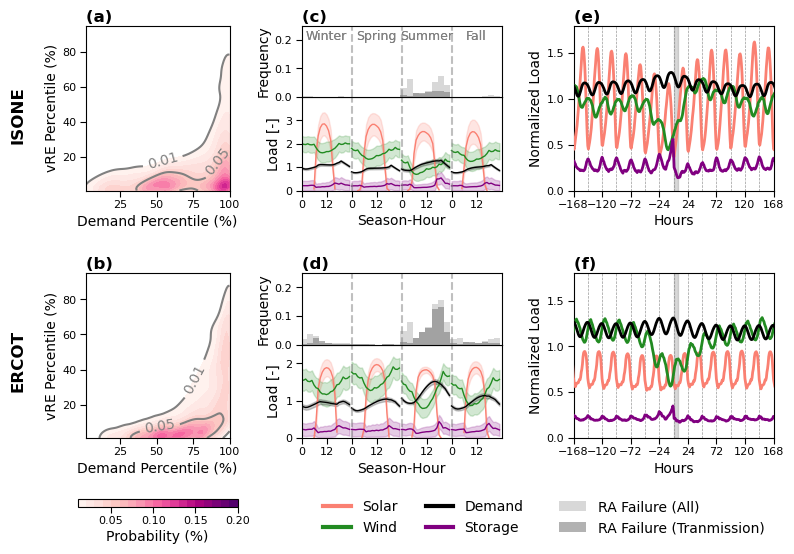

In [ ]:
items = ["solar-UPV_prod", "wind-onshore_prod", "Demand",'Strg_discharge']
itemcolor={'solar-UPV_prod':'solar','wind-onshore_prod':'wind','Demand':'demand','Strg_discharge':'strg'}
drought_dur={'ISONE':7.38,'ERCOT':7.12}
fig = plt.figure(figsize=(8,5.5))   
nrow=len(ISOs)
sce='historic'
drought_var='load_shedding'
ncol=3

xlocs=[0.03,0.30,0.64]
heights=0.3
subheight=0.17
width=[0.18,0.25,0.25]

for ir in range(nrow):
    ISO=ISOs[ir]
    yloc=0.725-0.45*ir

    ic=0
    xn='Demand'
    yn='RE'
    ax_joint=fig.add_axes((xlocs[ic], yloc, width[ic], heights))
    points_xr=xr.open_dataset('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_copula_%s_%s_%s_points.nc'%(inv_ny,ISO,rps,'rcp85hotter',xn,yn,'full'))
    points_xr_period=points_xr['Z_hist']
    prob=points_xr_period/points_xr_period.sum()*100 #probability(%)
    prob=prob[1:101,1:101] # 1th-100th percentiles
    U_grid, V_grid = np.meshgrid(np.linspace(1, 100, 100), np.linspace(1, 100, 100))
    contour_hist = ax_joint.contourf(U_grid, V_grid,prob ,cmap=cmaps.MPL_RdPu,levels=np.arange(1, 21, 1)*0.01)
    c_line=ax_joint.contour(U_grid, V_grid, prob,colors='grey',levels=[0.01,0.05])
    ax_joint.clabel(c_line, c_line.levels, fontsize=10)

    ax_joint.set_ylabel("vRE Percentile (%)")
    ax_joint.set_xlabel("Demand Percentile (%)")
    ax_joint.set_ylim(1,95)
    util.setsubtitle(ax_joint, f"", ni=ir)
    fig.text(xlocs[ic]-0.085, yloc+0.09, f"{ISO}", ha='center', fontsize=12, color='black', fontweight='bold',rotation=90)

    ic=1
    ax_generation = fig.add_axes((xlocs[ic], yloc, width[ic], subheight))
    ax_generation_drought = fig.add_axes((xlocs[ic], yloc+subheight, width[ic], heights-subheight))
    
    for metric in ['mean','std']:
        heatmap_metric_ens=[]
        for eid in range(seid,eeid+1):
            ofile_prefix='./Analysis_drought/%s_%s_RPS_%d_ny_%d-ens_%d_dispatch_Load_hourmonth' %(ISO, sce,rps,inv_ny,eid)
            DF_metric= pd.read_csv(f"{ofile_prefix}{metric}.csv")
            DF_metric['Season']=DF_metric['Month'].apply(util.get_season)

            heatmap_metric = DF_metric.groupby(['Season','Hour']).mean(numeric_only=True)
            heatmap_metric=heatmap_metric.replace(0,np.nan)
            heatmap_metric['ens']=eid
            heatmap_metric_ens.append(heatmap_metric)
        heatmap_metric_ens=pd.concat(heatmap_metric_ens)
        heatmap_metric_ensmean=heatmap_metric_ens.groupby(['Season','Hour']).mean(numeric_only=True).reset_index()
        if metric=='mean':
            heatmap_mean_ensmean=heatmap_metric_ensmean
            mean_demand=heatmap_mean_ensmean['Demand'].mean()
        elif metric=='std':
            heatmap_std_ensmean=heatmap_metric_ensmean

    for ss in range(1,5):
        toplot_mean=heatmap_mean_ensmean[heatmap_mean_ensmean['Season']==ss]
        toplot_mean=toplot_mean.copy()
        toplot_mean['Hour']=toplot_mean['Hour']+(ss-1)*24
        toplot_std=heatmap_std_ensmean[heatmap_std_ensmean['Season']==ss]
        toplot_std=toplot_std.copy()
        toplot_std['Hour']=toplot_std['Hour']+(ss-1)*24
        for item in items:
            if item=='sLev':
                continue
            toplot_mean[item]=toplot_mean[item]/mean_demand
            toplot_std[item]=toplot_std[item]/mean_demand
            ax_generation.plot(toplot_mean['Hour'],toplot_mean[item],color=colorpalattes[itemcolor[item]],linewidth=1)
            ax_generation.fill_between(x=toplot_mean['Hour'],y1=toplot_mean[item]-0.5*toplot_std[item],y2=toplot_mean[item]+0.5*toplot_std[item],
                                    color=colorpalattes[itemcolor[item]],alpha=0.2)
    if ir==0:
        ax_generation.set_ylim(0,4)
        ax_generation.set_yticks(np.arange(0,4,1))
    else:
        ax_generation.set_ylim(0,2.5)
        ax_generation.set_yticks(np.arange(0,3,1))
        
    ax_generation.set_xticks(np.arange(0,96,12))
    ax_generation.set_xticklabels([0,12,0,12,0,12,0,12])
    
    ax_generation.set_xlim(0,96)
    ax_generation.set_xlabel('Season-Hour')
    ax_generation.set_ylabel('Load [-]')
    
    for ih in range(2):
        if ih==0:
            DF_drought = pd.read_csv('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_heatmap.csv'%(inv_ny,ISO,rps,sce))
        else:
            DF_drought = pd.read_csv('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_heatmap_trans.csv'%(inv_ny,ISO,rps,sce))

        minyear=DF_drought['Year'].min()
        maxyear=DF_drought['Year'].max()
        new_index=pd.MultiIndex.from_product([range(minyear,maxyear+1),range(1,5),range(0,24),range(seid,eeid+1)],names=['Year','Season','Hour','id'])
        DF_drought['Season']=DF_drought['Month'].apply(util.get_season)
        DF_drought=DF_drought.groupby(['Year','Season','Hour','id']).mean(numeric_only=True).reset_index()
        DF_drought=DF_drought.set_index(['Year','Season','Hour','id']).reindex(new_index).fillna(0).reset_index()
        tmp_mean=DF_drought.groupby(['Season','Hour']).mean(numeric_only=True)[[drought_var]]
        tmp_mean=tmp_mean.replace(0,np.nan)
        pivot_mean=tmp_mean.reset_index().pivot(index='Season',columns='Hour',values=drought_var)

        tmp_toplot=[]
        for ss in range(1,5):
            toplot_mean=pivot_mean.loc[ss]
            toplot_mean=toplot_mean.to_frame().groupby(lambda x: x//3).sum().T
            toplot_mean.columns=(toplot_mean.columns*3+1)+(ss-1)*24
            toplot_mean.index=[0]
            tmp_toplot.append(toplot_mean)
            if ir==0:
                ax_generation_drought.text(12*(ss*2-1), 0.2, seasonsnames[ss], ha='center',fontsize=9, color='grey')


        toplot_mean=pd.concat(tmp_toplot,axis=1)
        toplot_mean=toplot_mean.replace(0,np.nan)
        x = toplot_mean.columns.to_numpy()
        y = toplot_mean.loc[0].to_numpy()
        mask = ~np.isnan(y)

        if ih==0:
            ax_generation_drought.bar(x[mask], y[mask],color='tab:grey',alpha=0.3,width=3,label='RA Failure (All)')
        else:
            ax_generation_drought.bar(x[mask], y[mask],color='tab:grey',alpha=0.6,width=3,label='RA Failure (Tranmission)')

    ax_generation_drought.set_xticks([])
    ax_generation_drought.set_ylabel('Frequency')        
    util.setsubtitle(ax_generation_drought, f"", ni=ir+2)
    ax_generation_drought.set_ylim(0,0.25)
    ax_generation_drought.set_xlim(0,96)

    # separate seasons
    for dh in [24,48,72]:
        ax_generation.axvline(dh,linestyle='dashed',color='grey',alpha=0.5)   
        ax_generation_drought.axvline(dh,linestyle='dashed',color='grey',alpha=0.5)   
    

    ic=2
    ax_process = fig.add_axes((xlocs[ic], yloc, width[ic], heights))
    dots_ens=pd.read_csv('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_hourly_dots_ensmean.csv'%(inv_ny,ISO,rps,sce))        
    dots=dots_ens[dots_ens['sce']==sce]
    dots=dots.groupby(['tindex']).mean(numeric_only=True).reset_index()
    for ica in range(4):
        item=items[ica]        
        sns.lineplot(data=dots, x='tindex', y=item, 
                color=colorpalattes[itemcolor[item]], linewidth=2, zorder=110,
                linestyle=linestyles[sce],errorbar=None,ax=ax_process)
    ax_process.set_xticks(np.arange(-168,168+48,48))

    #make a shade for drought period
    ymin=0
    ymax=1.8
    ax_process.fill_between(x=[0,drought_dur[ISO]],y1=ymin,y2=ymax,color='grey',alpha=0.3)
    ax_process.set_ylim(ymin,ymax)
    for x in np.arange(-168,168+24,24):
        ax_process.axvline(x=x, color='grey', linewidth=0.5, linestyle='--',alpha=0.8)
    ax_process.set_xlim(-168,168)

    ax_process.set_xlabel('Hours')
    ax_process.set_ylabel('Normalized Load')
    util.setsubtitle(ax_process, f"", ni=ir+4)

#colorbar
cbar_ax_joint = fig.add_axes([0.02,0.15,0.2,0.015])
cbar_joint = fig.colorbar(ax_joint.collections[0], cax=cbar_ax_joint, orientation='horizontal')
cbar_joint.set_label('Probability (%)')
cbar_ax_joint.set_xticks(np.arange(0.05, 0.25, 0.05))

#legend
for item in items:
    ax_process.plot([], [], color=colorpalattes[itemcolor[item]], label=tech_names[itemcolor[item]],linewidth=3)
ax_process.legend(loc='upper center', bbox_to_anchor=(-0.75, -0.30), ncol=2, frameon=False)

ax_generation_drought.legend(loc='upper center', bbox_to_anchor=(1.8, -2), ncol=1, frameon=False)
plt.savefig('./figures/drought_character.pdf', bbox_inches='tight', dpi=300)


## system

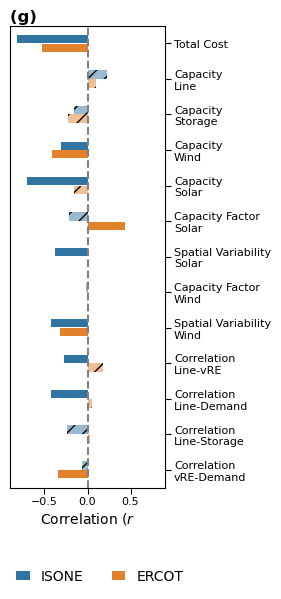

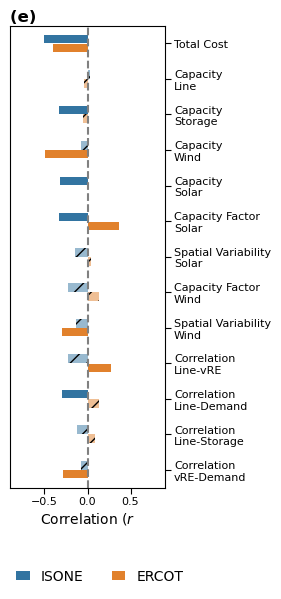

In [22]:
yvar='Occ'
vars=['total system cost','Line_total_cap','storage_total_cap',
'wind-onshore_total_cap','solar-UPV_total_cap',
'cf_solar-UPV','solar_sv',
'cf_wind-onshore','wind_sv',
'corr_line-vRE','corr_line-demand','corr_line-storage','corr_vRE-demand']
vars_labels={'total system cost':'Total Cost',
'Line_total_cap':'Capacity\nLine',
'storage_total_cap':'Capacity\nStorage',
'wind-onshore_total_cap':'Capacity\nWind',
'solar-UPV_total_cap':'Capacity\nSolar',
'cf_solar-UPV':'Capacity Factor\nSolar','cf_wind-onshore':'Capacity Factor\nWind',
'solar_sv':'Spatial Variability\nSolar','wind_sv':'Spatial Variability\nWind',
'wind_solar':'W-S','max_NL':'Peak\nNet Load',
'corr_line-vRE':'Correlation\nLine-vRE','corr_line-demand':'Correlation\nLine-Demand',
'corr_line-storage':'Correlation\nLine-Storage','corr_vRE-demand':'Correlation\nvRE-Demand'}
from scipy.stats import pearsonr, spearmanr

invsce='historic'
rps=1
alpha = 0.1  # FDR target

def bootstrap_pearson(x, y, n_iterations=1000):
    """
    Computes Pearson correlation and 95% CI using bootstrapping.
    """
    df = pd.DataFrame({'x': x, 'y': y}).dropna()
    n = len(df)
    if n < 5:
        return np.nan, np.nan, np.nan, np.nan
    
    # Observed correlation
    r_obs, p_obs = pearsonr(df['x'], df['y'])
    
    # Bootstrap samples
    boot_res = []
    indices = np.arange(n)
    for _ in range(n_iterations):
        resample_idx = np.random.choice(indices, size=n, replace=True)
        # Handle cases where resample has zero variance
        if df['x'].iloc[resample_idx].nunique() > 1 and df['y'].iloc[resample_idx].nunique() > 1:
            r_boot, _ = pearsonr(df['x'].iloc[resample_idx], df['y'].iloc[resample_idx])
            boot_res.append(r_boot)
    
    if len(boot_res) == 0:
        return r_obs, p_obs, np.nan, np.nan
        
    ci_low = np.percentile(boot_res, 2.5)
    ci_high = np.percentile(boot_res, 97.5)
    
    return r_obs, p_obs, ci_low, ci_high


n_boot=1000
for ir in range(2):
    sce=sces[ir]
    fig,ax1 = plt.subplots(figsize=(2.0, 6))
    DF=pd.DataFrame()
    all_results = []
    for ica in range(2):
        ISO=ISOs[ica]

        # --- capacity summary
        capacity_data=pd.read_csv('%s/%s_investment_summary.csv'%(mdir,ISO))
        cp_data=get_df(capacity_data,rps=rps,scenario=invsce,ny=inv_ny).reset_index().set_index('ensid')
        
        # load drought statistics
        if sce=='historic':
            DF_drought = pd.read_csv('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_drought_hourly.csv'%(inv_ny,ISO,rps,sce),index_col='id')
        else:
            DF_drought = pd.read_csv('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_b3_drought_hourly.csv'%(inv_ny,ISO,rps,sce),index_col='id') #2050-2059
        DF_drought['ISO']=ISO

        
        tmpISO=pd.merge(DF_drought,cp_data,right_index=True,left_index=True)

        # load system metrics
        input_prefix='./Analysis_drought/%s_%s_RPS_%d_ny_%d_dispatch' %(ISO, sce,rps,inv_ny)
        metrics=['SV_vRE','corr_vRE','mean']
        for metric in metrics:
            metric_tmp=pd.read_csv('%s_%s.csv' %(input_prefix,metric),index_col='id')
            tmpISO=pd.merge(tmpISO,metric_tmp,left_index=True,right_index=True)
        
        input_prefix='./Analysis_drought/%s_%s_RPS_%d_ny_%d_dispatch' %(ISO, 'historic',rps,inv_ny)
        metric='corr_line'
        metric_tmp=pd.read_csv('%s_%s.csv' %(input_prefix,metric),index_col='id')
        tmpISO=pd.merge(tmpISO,metric_tmp,left_index=True,right_index=True)
        # --- compute correlations for requested vars
        for var in vars:
            r, p, ci_l, ci_h = bootstrap_pearson(tmpISO[yvar], tmpISO[var], n_iterations=n_boot)
            
            # Robustness check: Spearman
            r_spearman, p_spearman = spearmanr(tmpISO[yvar], tmpISO[var], nan_policy='omit')
            all_results.append({
                'ISO': ISO,
                'var': var,
                'corr': r,
                'p_value': p,
                'ci_low': ci_l,
                'ci_high': ci_h,
                'spearman_r': r_spearman,
                'spearman_p': p_spearman,
                'label': vars_labels.get(var, var)
            })


    DF = pd.DataFrame(all_results)
    DF['signif'] = (DF['p_value'] <= alpha).fillna(False)
    DF['nosignif'] = (DF['p_value'] > alpha).fillna(False)
    # --- y order and labels
    y_order_labels = [vars_labels.get(v, v) for v in vars]


    # split for styling
    DF_sig=DF.copy()
    DF_nonsig=DF.copy()
    DF_sig.loc[~DF_sig['signif'], 'corr'] = 0
    DF_nonsig.loc[DF_nonsig['signif'], 'corr'] = 0
   
    sns.barplot(data=DF_sig,y='label',x='corr',hue='ISO',ax=ax1,legend=True,hue_order=ISOs,palette=ISO_palettes,width=0.5,gap=0.1, order=[vars_labels.get(v, v) for v in y_order_labels])
    sns.barplot(data=DF_nonsig,y='label',x='corr',hue='ISO',ax=ax1,legend=False,alpha=0.5,hatch='//',hue_order=ISOs,palette=ISO_palettes,width=0.5, order=[vars_labels.get(v, v) for v in y_order_labels])
    ax1.set_xlabel(r'Correlation ($r$')
    ax1.set_ylabel(f'')
    ax1.set_xlim(-0.9,0.9)
    ax1.axvline(0,linestyle='--',color='grey')
    ax1.yaxis.tick_right()
    if sce=='historic':
        util.setsubtitle(ax1, f"", ni=6)
    else:
        util.setsubtitle(ax1, f"", ni=4)
    sns.move_legend(ax1, "upper right", bbox_to_anchor=(1.2, -0.15), ncol=2, title=None, frameon=False,
    handlelength=1)
    plt.savefig('./figures/correlation_%s.pdf'%sce, bbox_inches='tight', dpi=300)

# climate change

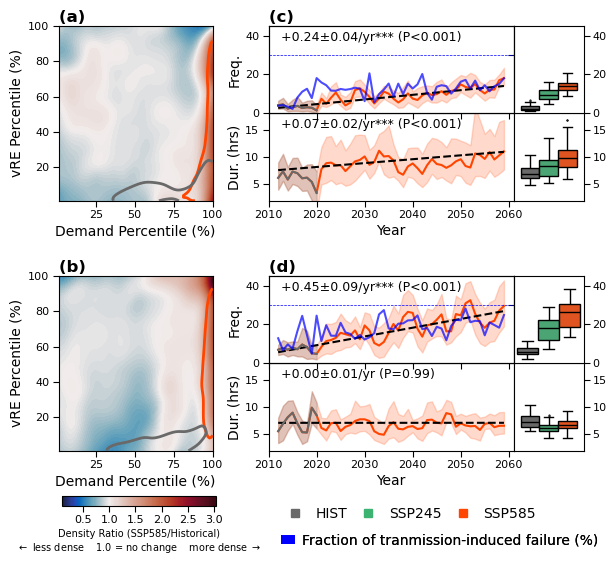

In [ ]:
nrs=2
fig = plt.figure(figsize=(7, 5))
levels_diff = np.arange(0.1, 3.06, 0.02)
diff_norm = TwoSlopeNorm(vmin=0.1, vcenter=1.0, vmax=3.0)
sce='rcp85hotter'
xlocs=[0.02,0.32,0.67]
widths=[0.22,0.35,0.1]
height=0.35
yn='RE'
xn='Demand'

ic=0
for ir in range(nrs):
    yloc=0.65-0.5*ir
    ax_joint=fig.add_axes((xlocs[ic], yloc, widths[ic], height))
    ISO=ISOs[ir]
    Z_xr=xr.open_dataset('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_copula_%s_%s_%s.nc'%(inv_ny,ISO,rps,sce,xn,yn,'full'))
    diff_density = (Z_xr.Z_future/Z_xr.Z_hist)  #Compute density difference
    diff_density=diff_density[1:101,1:101]
    contour_diff = ax_joint.contourf(diff_density[xn]*100, diff_density[yn]*100, diff_density, cmap=cmaps.cmocean_balance, levels=levels_diff, norm=diff_norm)
    ax_joint.set_xlabel("Demand Percentile (%)")
    ax_joint.set_ylabel("vRE Percentile (%)")

    points_xr=xr.open_dataset('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_copula_%s_%s_%s_points.nc'%(inv_ny,ISO,rps,sce,xn,yn,'full'))
    
    for sce_tmp in ['historic',sce]:
        if sce_tmp=='historic':
            points_xr_period=points_xr['Z_hist']
        else:
            points_xr_period=points_xr['Z_future']
        prob=points_xr_period/points_xr_period.sum()*100
        prob=prob[1:101,1:101]
        U_grid, V_grid = np.meshgrid(np.linspace(0.01, 1, 100), np.linspace(0.01, 1, 100))
        if sce_tmp=='historic':
            c=ax_joint.contour(U_grid*100, V_grid*100, prob, colors=colorpalattes[sce_tmp],linewidths=2,levels=[0.05],zorder=200)
        else:
            c=ax_joint.contour(U_grid*100, V_grid*100, prob, colors=colorpalattes[sce_tmp],linewidths=2,levels=[0.05])
    util.setsubtitle(ax_joint, "", ni=ir)

####################
vars=['dur','occ']
vars_box={'dur':'DurMean','occ':'Occ'}
vars_labels={'occ':'Freq.','dur':'Dur. (hrs)'}

tmp=pd.DataFrame()
for ir in range(nrs):
    ISO=ISOs[ir]
    for scea in ['historic','rcp85hotter','rcp45hotter']:
        if scea=='historic':
            DF_drought = pd.read_csv('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_drought_hourly.csv'%(inv_ny,ISO,rps,'historic'))
        else:
            DF_drought = pd.read_csv('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_b3_drought_hourly.csv'%(inv_ny,ISO,rps,scea))
        DF_drought['ISO']=ISO
        tmp=pd.concat([tmp,DF_drought])
tmp=tmp.reset_index()

for ir in range(nrs):
    ISO=ISOs[ir]
    yloc=0.65-0.5*ir
    iso_tmp=tmp[tmp['ISO']==ISO]
    for ivr,var in enumerate(vars):
        var_box=vars_box[var]
        yloc_sub=yloc+height/2*ivr

        ax_line=fig.add_axes((xlocs[1], yloc_sub, widths[1], height/2))
        ax_box=fig.add_axes((xlocs[2], yloc_sub, widths[2], height/2))

        for ih in range(2):
            if ih==0:
                hist=pd.read_csv('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_heatmap.csv'%(inv_ny,ISO,rps,'historic'))
            else:
                hist=pd.read_csv('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_heatmap_trans.csv'%(inv_ny,ISO,rps,'historic'))
            hist_dur=hist.groupby(['id','Year']).mean(numeric_only=True)[['dur','mag']]
            hist_occ=hist.groupby(['id','Year']).sum(numeric_only=True)[['occ']]
            hist=pd.merge(hist_dur,hist_occ,left_index=True,right_index=True).reset_index()
            minyear=hist['Year'].min()
            maxyear=hist['Year'].max() 
            new_index=pd.MultiIndex.from_product([range(seid,eeid+1),range(minyear,maxyear+1),],names=['id','Year'])
            hist=hist.set_index(['id','Year']).reindex(new_index).fillna(0).reset_index()
            hist =hist[hist['Year'].isin(hist_years)]
            hist=hist.groupby(['id','Year']).mean(numeric_only=True)
            hist['sce']='historic'
            hist=hist.reset_index()
            hist=hist.set_index(['id','Year'])
            future=hist

            for pid in range(4):
                if ih==0:
                    futuretmp = pd.read_csv('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_b%d_heatmap.csv'%(inv_ny,ISO,rps,'rcp85hotter',pid))
                else:
                    futuretmp = pd.read_csv('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_b%d_heatmap_trans.csv'%(inv_ny,ISO,rps,'rcp85hotter',pid))
                futuretmp_dur=futuretmp.groupby(['id','Year']).mean(numeric_only=True)[['dur','mag']]
                futuretmp_occ=futuretmp.groupby(['id','Year']).sum(numeric_only=True)[['occ']]
                futuretmp=pd.merge(futuretmp_dur,futuretmp_occ,left_index=True,right_index=True).reset_index()
                minyear=futuretmp['Year'].min()
                maxyear=futuretmp['Year'].max()
                new_index=pd.MultiIndex.from_product([range(seid,eeid+1),range(minyear,maxyear+1),],names=['id','Year'])
                futuretmp=futuretmp.set_index(['id','Year']).reindex(new_index).fillna(0).reset_index()
                futuretmp=futuretmp.groupby(['id','Year']).mean(numeric_only=True)
                futuretmp['sce']=sce
                future=pd.concat([future,futuretmp])
            future['sce']=sce
            future_thours=future['dur']*future['occ']
            if ih==0:
                total_outage=future_thours
            elif ih==1:
                trans_outage=future_thours

            if ih==0:
                yearmean=future.rolling(window=2).mean(numeric_only=True).reset_index()
                # --- Plotting Line ---
                sns.lineplot(data=yearmean,x='Year',y=var,ax=ax_line,legend=False,
                            errorbar=('pi', 90),color=colorpalattes[sce])
                # --- Trend Analysis ---
                grouped=yearmean.groupby('Year').mean().reset_index()
                X = grouped['Year'].values.reshape(-1, 1)
                y=grouped[var].values
                model=TheilSenRegressor().fit(X, y)
                y_pred = model.predict(X)
                slope = model.coef_[0]
                mad = median_abs_deviation(y, scale='normal')
                slope_std = mad / (np.sqrt(len(y)) * np.std(X)) 
                mk_result = mk.original_test(y)
                p_value = mk_result.p
                stars=util.get_sig_stars(p_value)


                ax_line.plot(grouped['Year'],y_pred,label=f'slope={slope:.2f}, p={p_value:.2f}',color='k',linestyle='--')
                sns.lineplot(data=yearmean[yearmean['Year']<=2020],x='Year',y=var,ax=ax_line,legend=False,errorbar=('pi', 90),color=colorpalattes['historic'])
                y_pos = 0.85 

                if p_value<0.001:
                    stars='*** (P<0.001)'
                elif p_value<0.01:
                    stars='** (P<0.01)'
                if p_value<0.001:
                    ax_line.text(0.05,0.83, 
                                f"{slope:+.2f}±{slope_std:.2f}/yr{stars}", fontsize=9, 
                                ha='left', transform=ax_line.transAxes)
                else:
                    ax_line.text(0.05,0.83, 
                                f"{slope:+.2f}±{slope_std:.2f}/yr (P={p_value:.2f})", fontsize=9, 
                                ha='left', transform=ax_line.transAxes)
                    
            else:
                if var=='occ':
                    yearmean=trans_outage/total_outage
                    yearmean=yearmean.reset_index()
                    yearmean=yearmean.groupby('Year').mean().reset_index()
                    axb=ax_line.twinx()
                    axb.plot(yearmean['Year'],yearmean[0],color='blue',label='Fraction of hours',alpha=0.7)
                    axb.set_ylim(0,1.5)
                    axb.set_yticks([1])
                    axb.set_yticklabels([])
                    axb.set_ylabel('',color='blue')
                    axb.tick_params(axis='y', direction='in',pad=-20)
                    axb.axhline(y=1,linestyle='--',color='blue',linewidth=0.5)
        
        sns.boxplot(ax=ax_box,x='ISO',y=var_box,data=iso_tmp,hue='sce',palette=colorpalattes,
                hue_order=['historic','rcp45hotter','rcp85hotter'],legend=False,fliersize=0.5)

        if var=='occ':
            ax_line.set_ylim(0,45)
            ax_box.set_ylim(0,45)
        elif var=='dur':
            ax_box.set_ylim(2,18)
            ax_box.set_yticks([5,10,15])
            ax_line.set_ylim(2,18)
        
        if ivr==0:
            ax_line.set_xlabel('Year')
        else:
            ax_line.set_xlabel('')
            ax_line.set_xticklabels([])
        ax_line.set_ylabel(vars_labels[var])
        ax_line.set_xlim([2010,2061])
        ax_box.set_xlabel("") 
        ax_box.set_xticks([])
        ax_box.set_ylabel('')
        ax_box.yaxis.set_ticks_position('right')
        util.setsubtitle(ax_line, f"", ni=ir+2)

cax_cbar_diff= fig.add_axes([xlocs[0]+0.005, 0.04, widths[0], 0.02])
cbar_diff = fig.colorbar(contour_diff, cax=cax_cbar_diff, orientation='horizontal', pad=0.02)
cax_cbar_diff.set_xlabel('Density Ratio\n(SSP585/Historical)')
cax_cbar_diff.set_xticks(np.arange(0.5, 3.4, 0.5))
cax_cbar_diff.set_xlabel('Density Ratio (SSP585/Historical)\n'
                          r'$\leftarrow$ less dense    1.0 = no change    more dense $\rightarrow$',
                          fontsize=7)

for scea in ['historic','rcp45hotter','rcp85hotter']:
    ax_box.plot([], [], color=colorpalattes[scea], label=scenario_labels[scea],marker='s',linestyle='None')
legend_fraction = [mpatches.Patch(facecolor='blue', label='Fraction of tranmission-induced failure (%)') ]
lg_normal=ax_box.legend(loc='upper left', bbox_to_anchor=(-3.5, -1.5),ncol=3,labelspacing=0.1,
handletextpad=0.5,columnspacing=0.5,frameon=False)
lg_fraction = ax_box.legend(handles=legend_fraction, loc='upper left', labelspacing=0.1,
                         handletextpad=0.5,columnspacing=0.5, frameon=False, 
                         bbox_to_anchor=(-3.5, -1.8),handlelength=1)
ax_box.add_artist(lg_fraction)
ax_box.add_artist(lg_normal)
plt.savefig('./figures/climate_change.pdf', bbox_inches='tight', dpi=300)
plt.show()

dur
The trends are significantly different.
occ
The trends are significantly different.
dur
The trends are significantly different.
occ
The trends are significantly different.


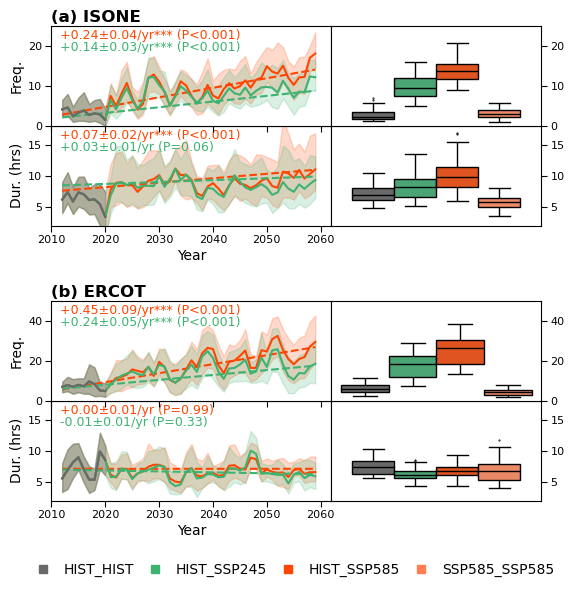

In [ ]:
nrs=2
fig = plt.figure(figsize=(7, 5))
sce='rcp45hotter'
xlocs=[0.1,0.5]
widths=[0.4,0.3]
height=0.4

####################
vars=['dur','occ']
vars_box={'dur':'DurMean','occ':'Occ'}
vars_labels={'occ':'Freq.','dur':'Dur. (hrs)'}

tmp=pd.DataFrame()
for ir in range(nrs):
    ISO=ISOs[ir]
    for scea in ['historic','rcp85hotter','rcp45hotter','rcp85hotter_oos']:
        if scea=='historic':
            DF_drought = pd.read_csv('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_drought_hourly.csv'%(inv_ny,ISO,rps,'historic'))
        elif scea in ['rcp85hotter','rcp45hotter']:
            DF_drought = pd.read_csv('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_b3_drought_hourly.csv'%(inv_ny,ISO,rps,scea))
        elif scea=='rcp85hotter_oos':
            DF_drought = pd.read_csv('./Analysis_drought/oos_ny_%d_%s_RPS_%d_%s_drought_hourly.csv'%(inv_ny,ISO,rps,'rcp85hotter'))
        DF_drought['ISO']=ISO
        DF_drought['Occ']=DF_drought['Occ']
        DF_drought['sce']=scea
        tmp=pd.concat([tmp,DF_drought])
tmp=tmp.reset_index()

for ir in range(2):
    ISO=ISOs[ir]
    yloc=0.65-0.55*ir
    iso_tmp=tmp[tmp['ISO']==ISO]
    for ivr,var in enumerate(vars):
        var_box=vars_box[var]
        yloc_sub=yloc+height/2*ivr

        ax_line=fig.add_axes((xlocs[0], yloc_sub, widths[0], height/2))
        ax_box=fig.add_axes((xlocs[1], yloc_sub, widths[1], height/2))

        scenario_slopes = {}
        for sce in ['rcp85hotter','rcp45hotter']:
            hist=pd.read_csv('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_heatmap.csv'%(inv_ny,ISO,rps,'historic'))
            hist_dur=hist.groupby(['id','Year']).mean(numeric_only=True)[['dur','mag']]
            hist_occ=hist.groupby(['id','Year']).sum(numeric_only=True)[['occ']]
            hist=pd.merge(hist_dur,hist_occ,left_index=True,right_index=True).reset_index()
            minyear=hist['Year'].min()
            maxyear=hist['Year'].max() 
            new_index=pd.MultiIndex.from_product([range(seid,eeid+1),range(minyear,maxyear+1),],names=['id','Year'])
            hist=hist.set_index(['id','Year']).reindex(new_index).fillna(0).reset_index()
            hist =hist[hist['Year'].isin(hist_years)]
            hist=hist.groupby(['id','Year']).mean(numeric_only=True)
            hist['sce']='historic'
            hist=hist.reset_index()
            hist=hist.set_index(['id','Year'])
            future=hist

            for pid in range(4):
                futuretmp = pd.read_csv('./Analysis_drought/OutSampleDispatch_ny_%d_%s_RPS_%d_%s_b%d_heatmap.csv'%(inv_ny,ISO,rps,sce,pid))
                futuretmp_dur=futuretmp.groupby(['id','Year']).mean(numeric_only=True)[['dur','mag']]
                futuretmp_occ=futuretmp.groupby(['id','Year']).sum(numeric_only=True)[['occ']]
                futuretmp=pd.merge(futuretmp_dur,futuretmp_occ,left_index=True,right_index=True).reset_index()
                minyear=futuretmp['Year'].min()
                maxyear=futuretmp['Year'].max()
                new_index=pd.MultiIndex.from_product([range(seid,eeid+1),range(minyear,maxyear+1),],names=['id','Year'])
                futuretmp=futuretmp.set_index(['id','Year']).reindex(new_index).fillna(0).reset_index()
                futuretmp=futuretmp.groupby(['id','Year']).mean(numeric_only=True)
                futuretmp['sce']=sce
                future=pd.concat([future,futuretmp])
            future['sce']=sce
            future_thours=future['dur']*future['occ']
            total_outage=future_thours
            yearmean=future.rolling(window=2).mean(numeric_only=True).reset_index()

            # --- Plotting Line ---
            sns.lineplot(data=yearmean,x='Year',y=var,ax=ax_line,legend=False,
                        errorbar=('pi', 90),color=colorpalattes[sce])
            # --- Trend Analysis ---
            grouped=yearmean.groupby('Year').mean().reset_index()
            X = grouped['Year'].values.reshape(-1, 1)
            y=grouped[var].values

            model=TheilSenRegressor().fit(X, y)
            y_pred = model.predict(X)
            slope = model.coef_[0]
            mad = median_abs_deviation(y, scale='normal')
            slope_std = mad / (np.sqrt(len(y)) * np.std(X))
            mk_result = mk.original_test(y)
            p_value = mk_result.p
            stars=util.get_sig_stars(p_value)
            ax_line.plot(grouped['Year'],y_pred,color=colorpalattes[sce],linestyle='--')
            
            
            sns.lineplot(data=yearmean[yearmean['Year']<=2020],x='Year',y=var,ax=ax_line,legend=False,errorbar=('pi', 90),color=colorpalattes['historic'])

            if var=='occ':
                y_max=25 if ISO=='ISONE' else 50
                ax_line.set_ylim(0,y_max)
            elif var=='dur':
                ax_line.set_ylim(2,18)
                ax_line.set_yticks([5,10,15])

            if ivr==0:
                ax_line.set_xlabel('Year')
            else:
                ax_line.set_xlabel('')
                ax_line.set_xticklabels([])
            ax_line.set_ylabel(vars_labels[var])
            ax_line.set_xlim([2010,2062])
            util.setsubtitle(ax_line, ISO, ni=ir)
            y_pos = 0.87 if sce == 'rcp85hotter' else 0.75
            if p_value<0.001:
                    stars='*** (P<0.001)'
            elif p_value<0.01:
                stars='** (P<0.01)'

            if p_value<0.001:
                ax_line.text(0.03,y_pos, 
                            f"{slope:+.2f}±{slope_std:.2f}/yr{stars}", fontsize=9, color=colorpalattes[sce],
                            ha='left', transform=ax_line.transAxes)
            else:
                ax_line.text(0.03,y_pos,
                            f"{slope:+.2f}±{slope_std:.2f}/yr (P={p_value:.2f})", fontsize=9, color=colorpalattes[sce],
                            ha='left', transform=ax_line.transAxes)


    
            scenario_slopes[sce] = get_ensemble_slopes(yearmean.dropna(), var)
        
        sns.boxplot(ax=ax_box,x='ISO',y=var_box,data=iso_tmp,hue='sce',palette=colorpalattes,
            hue_order=['historic','rcp45hotter','rcp85hotter','rcp85hotter_oos'],legend=False,fliersize=0.5)    

        if var=='occ':
            y_max=25 if ISO=='ISONE' else 50
            ax_box.set_ylim(0,y_max)
        elif var=='dur':
            ax_box.set_ylim(2,18)
            ax_box.set_yticks([5,10,15])
        ax_box.set_xlabel("") 
        ax_box.set_xticks([])
        ax_box.set_xticklabels([])
        ax_box.set_ylabel('')
        ax_box.yaxis.set_ticks_position('right')
        t_stat, p_val = ttest_ind(scenario_slopes['rcp45hotter'], 
                                        scenario_slopes['rcp85hotter'], equal_var=False)
        print(var)
        if p_val < 0.05:
            print("The trends are significantly different.")
        else:
            print("No significant difference detected between trends.")

scenario_labels_oos={'historic':'HIST_HIST','rcp45hotter':'HIST_SSP245',
'rcp85hotter':'HIST_SSP585','rcp85hotter_oos':'SSP585_SSP585'}
for scea in ['historic','rcp45hotter','rcp85hotter','rcp85hotter_oos']:
    ax_box.plot([], [], color=colorpalattes[scea], label=scenario_labels_oos[scea],marker='s',linestyle='None')
lg_normal=ax_box.legend(loc='upper left', bbox_to_anchor=(-1.5, -1.5),ncol=4,labelspacing=0.1,
handletextpad=0.5,columnspacing=0.5,frameon=False)

plt.savefig('./figures/climate_change_SSPcomparison.pdf', bbox_inches='tight', dpi=300)
plt.show()

## Siting maps

/orcd/nese/mhowland/001/lyqiu/GODEEP/NE_2025/Modules_utility_analysis.py:152: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=90, va='center')
/orcd/nese/mhowland/001/lyqiu/GODEEP/NE_2025/Modules_utility_analysis.py:152: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=90, va='center')


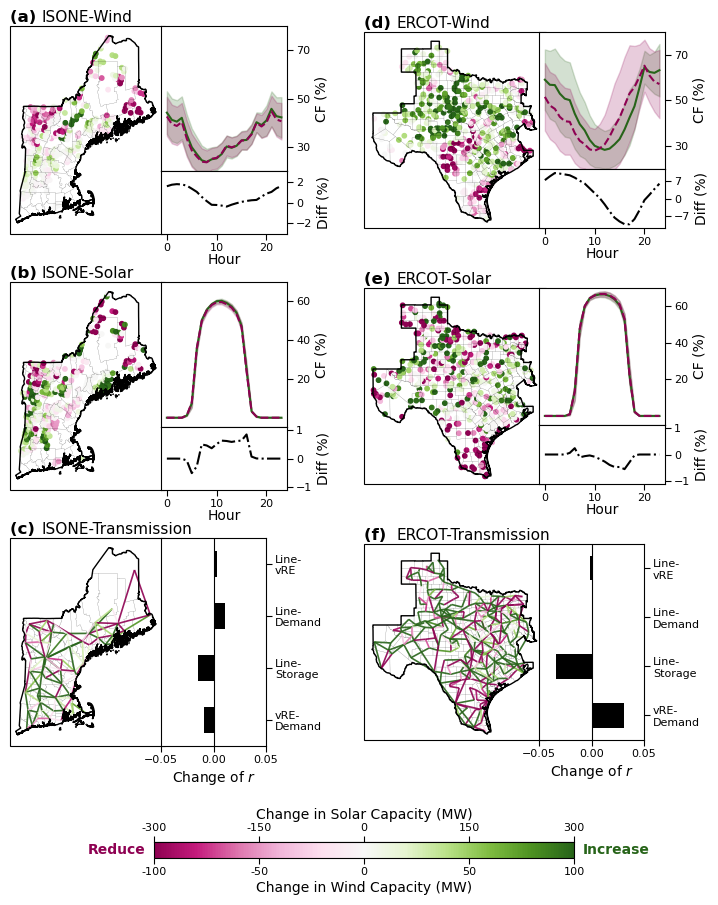

In [ ]:
fig = plt.figure(figsize=(7,8))  
sces=['historic','rcp85hotter']
techs=['wind-onshore','solar-UPV','line']
techlabels={'wind-onshore':'wind','solar-UPV':'solar','line':'line'}
y1locs=[0.75,0.43,0.11]
y2locs=[0.75,0.43,0.11]
xlocs=[0.03,0.55]
clos='PiYG'
vars=['corr_line-vRE','corr_line-demand','corr_line-storage','corr_vRE-demand']
# --- 1. Pre-process Correlation Differences ---
diff_corr_list = []
for ISO in ISOs:
    iso_results = []
    for sce in sces: # historic vs future
        cp_data = get_df(pd.read_csv(f'{mdir}/{ISO}_investment_summary.csv'), 
                         ny=inv_ny, scenario=sce, rps=rps).reset_index().set_index('ensid')
        metric_tmp = pd.read_csv(f'./Analysis_drought/{ISO}_{sce}_RPS_{rps}_ny_{inv_ny}_dispatch_corr_line_self.csv', index_col='id')
        merged = pd.merge(metric_tmp, cp_data, left_index=True, right_index=True)
        means = merged[vars].mean().to_frame(name='value')
        means['ISO'] = ISO
        means['sce'] = sce
        iso_results.append(means)
    # Calculate Delta (Future - Historic)
    delta = iso_results[1]['value'] - iso_results[0]['value']
    delta_df = delta.to_frame().reset_index().rename(columns={'index': 'x'})
    delta_df['ISO'] = ISO
    diff_corr_list.append(delta_df)
diff_corr = pd.concat(diff_corr_list)
diff_corr['x_label'] = diff_corr['x'].map(vars_labels).fillna(diff_corr['x'])


# --- 2. Main Plotting Loop ---
axes = {} # Registry to keep track of axes by (ISO, Tech)

vars_labels={'total system cost':'Total Cost',
'Line_total_cap':'Capacity\nLine',
'storage_total_cap':'Capacity\nStorage',
'wind-new_total_cap':'Capacity\nWind',
'solar-UPV_total_cap':'Capacity\nSolar',
'cf_solar-UPV':'CF\nSolar','cf_wind-new':'CF\nWind',
'solar_sv':'SV\nSolar','wind_sv':'SV\nWind',
'wind_solar':'W-S','max_NL':'Peak\nNet Load',
'corr_line-vRE':'Line-\nvRE','corr_line-demand':'Line-\nDemand',
'corr_line-storage':'Line-\nStorage','corr_vRE-demand':'vRE-\nDemand'}
rps=1
cmap = plt.get_cmap(clos)
positive_color = cmap(1.0)
negative_color = cmap(0.0)


for ir,sce in enumerate(sces):
    DF = pd.DataFrame()
    for ica in range(2):
        ISO=ISOs[ica]
        sdata=pd.read_csv('%s/%s_investment_summary.csv'%(mdir,ISO))
        cp_data=get_df(sdata,ny=inv_ny,scenario=sce,rps=rps).reset_index().set_index('ensid')  
        metric_file='./Analysis_drought/%s_%s_RPS_%d_ny_%d_dispatch_corr_line_self.csv' %(ISO, sce,rps,inv_ny)
        metric_tmp=pd.read_csv(metric_file,index_col='id')
        tmpISO=pd.merge(metric_tmp,cp_data,right_index=True,left_index=True)
        
        # --- compute correlations for requested vars
        for var in vars:
            df=pd.DataFrame({'ISO':[ISO],'value':[tmpISO[var].mean()],'x':[var]})
            DF=pd.concat([DF,df])

    y_order = vars[:] 
    DF['x_label'] = DF['x'].map(vars_labels).fillna(DF['x'])

    if ir==0:
        DF_hist=DF.copy().set_index(['ISO','x_label']).drop(columns=['x'])
    else:
        DF_future=DF.copy().set_index(['ISO','x_label']).drop(columns=['x'])
diff_corr=(DF_future-DF_hist)
diff_corr=diff_corr.reset_index()




ni=0
for ic, ISO in enumerate(ISOs):
    counties = gpd.read_file(f'./ISO_county/{ISO}.shp')
    outline = counties.dissolve()
    for ir, tech in enumerate(techs):
        ax_key=(ISO,tech)
        if ic==0:
            axes[ax_key]=fig.add_axes((xlocs[ic], y1locs[ir], 0.25, 0.26),projection=ccrs.PlateCarree())
        else:
            axes[ax_key]=fig.add_axes((xlocs[ic], y2locs[ir], 0.26, 0.26),projection=ccrs.PlateCarree())
        
        ax=axes[ax_key]
        util.setupmapbg(ax, ISO)
        outline.boundary.plot(ax=ax, color='black', linewidth=1.0,  alpha=1,zorder=5)
        counties.boundary.plot(ax=ax, color='black', linewidth=0.1, alpha=0.5)
        util.setup_map_panel_ticks(ax,1,ir,2,f"",f"")
        util.setsubtitle(ax,"",ni=ni)
        ni+=1

        if ISO=='ISONE':
            ax.text(0.20,1.04, f"{ISO}-{tech_names[tech]}",fontsize=11, ha='left', va='center', transform=ax.transAxes)
        elif ISO=='ERCOT':
            ax.text(0.18,1.04, f"{ISO}-{tech_names[tech]}",fontsize=11, ha='left', va='center', transform=ax.transAxes)

        if tech in ['wind-onshore', 'solar-UPV']:
            loc_hist=pd.read_csv(f'{mdir}/result_{ISO}_inv/RPS_1_ny_2_historic_{tech}_capacity_grouped.csv',index_col=['lat','lon']).drop(columns=['name'])
            loc_future=pd.read_csv(f'{mdir}/result_{ISO}_inv/RPS_1_ny_2_rcp85hotter_{tech}_capacity_grouped.csv',index_col=['lat','lon']).drop(columns=['name'])
            loc_hist=  loc_hist.clip(lower=1)
            loc_future= loc_future.clip(lower=1)            
            locations_diff=(loc_future-loc_hist).reset_index()

            vmax=100 if tech=='wind-onshore' else 300
            sm=ax.scatter(locations_diff['lon'], locations_diff['lat'],c=locations_diff['Total_capacity'],cmap=clos,vmin=-vmax,vmax=vmax,s=10)
            if tech=='wind-onshore': cw=sm
            elif tech=='solar-UPV': cs=sm

            ds=xr.open_dataset(f"{metdir}/{sce}/{techlabels[tech]}/{ISO}/{techlabels[tech]}_gen_cf_annual_monthly_dhourmean.nc")['capacity_factor']            
            try:
                times=pd.Series(ds['Time'].values).apply(parse_timestamp)
            except:
                try:
                    times=pd.to_datetime(ds['Time'].values)
                except:
                    times=pd.to_datetime([str(ds['Time'].values[i]) for i in range(len(ds['Time'].values))])
            ds['lat']=ds['lat'].round(3)
            ds['lon']=ds['lon'].round(3)
            ds['Time']=times
            ds_sub=ds.sel(Time=slice('2050-01-01','2059-12-31'))
            ds_sub=ds_sub.sel(Time=ds_sub.Time.dt.month.isin([6,7,8,9]))
            ds_sub=ds_sub.stack(z=('y', 'x')).dropna(dim='z')

            CF_df=ds_sub.to_dataframe()[['capacity_factor', 'lat', 'lon']].reset_index()
            CF_df['capacity_factor']=CF_df['capacity_factor']*100
            CF_df['local_time']=CF_df['Time'].dt.tz_localize('UTC').dt.tz_convert(tzs[ISO])
            CF_df['Hour']=CF_df['local_time'].dt.hour
            CF_df_diff_mean=CF_df.groupby(['lat','lon','Hour']).mean().reset_index()
            CF_df_diff_mean=pd.merge(CF_df_diff_mean,locations_diff,left_on=['lat','lon'],right_on=['lat','lon'],how='right')


            if ic==0:
                xloc_sub=xlocs[ic]+0.23
            else:
                xloc_sub=xlocs[ic]+0.25
            locs=ax.get_position()
            ax_se=fig.add_axes((xloc_sub, locs.y0+locs.height*0.3, 0.18, locs.height*0.7))
            ax_diff=fig.add_axes((xloc_sub, locs.y0, 0.18, locs.height*0.3))

            postive_capacity=CF_df_diff_mean[CF_df_diff_mean['Total_capacity']>0]
            sns.lineplot(data=postive_capacity,x='Hour',y='capacity_factor',legend=False,ax=ax_se,c=positive_color,
                                errorbar=('sd', 1),linestyle='-')
            postive_line=postive_capacity.groupby(['Hour']).mean().reset_index()

            negative_capacity=CF_df_diff_mean[CF_df_diff_mean['Total_capacity']<0]
            sns.lineplot(data=negative_capacity,x='Hour',y='capacity_factor',legend=False,ax=ax_se,c=negative_color,
                                errorbar=('sd', 1),linestyle='--')
            negative_line=negative_capacity.groupby(['Hour']).mean().reset_index()

            diff=postive_line-negative_line
            ax_diff.plot(diff.index,diff['capacity_factor'],linestyle='-.',color='black')
            ax_se.yaxis.tick_right()
            ax_se.yaxis.set_label_position("right")
            ax_diff.yaxis.tick_right()
            ax_diff.yaxis.set_label_position("right")
            ax_se.set_ylabel('CF (%)')
            if tech=='wind-onshore':
                ax_se.set_ylim(20,80)
                ax_se.set_yticks([30,50,70])
            elif tech=='solar-UPV':
                ax_se.set_ylim(-5,70)
                ax_se.set_yticks([20,40,60])
            
            ax_diff.set_ylabel("Diff (%)")
            if tech=='wind-onshore':
                if ISO=='ISONE':
                    ax_diff.set_ylim(-3,3)
                    ax_diff.set_yticks([-2,0,2])
                elif ISO=='ERCOT':
                    ax_diff.set_ylim(-12,12)
                    ax_diff.set_yticks([-7,0,7])
            elif tech=='solar-UPV':
                ax_diff.set_ylim(-1.1,1.1)
                ax_diff.set_yticks([-1,0,1])

            ax_diff.set_xlabel('Hour',labelpad=0.2)
            ax_se.set_xlabel('')
        else:
            loc_hist=pd.read_csv(f'{mdir}/result_{ISO}_inv/RPS_1_ny_2_historic_{tech}_capacity_grouped.csv')
            loc_future=pd.read_csv(f'{mdir}/result_{ISO}_inv/RPS_1_ny_2_rcp85hotter_{tech}_capacity_grouped.csv')

            loc_hist=loc_hist.set_index(['from_lat','from_lon','to_lat','to_lon']).drop(columns=['from_node','to_node'])
            loc_hist=   loc_hist.clip(lower=1)
            loc_future=loc_future.set_index(['from_lat','from_lon','to_lat','to_lon']).drop(columns=['from_node','to_node'])
            loc_future=   loc_future.clip(lower=1)
            locations_diff=(loc_future-loc_hist).reset_index()

            segments = locations_diff[['from_lon', 'from_lat', 'to_lon', 'to_lat']].values.reshape(-1, 2, 2)
            capacities = locations_diff['Total_capacity'].values
            lc = LineCollection(
                    segments, 
                    cmap='PiYG', 
                    norm=plt.Normalize(vmin=-50, vmax=50),
                    transform=ccrs.PlateCarree(),
                    zorder=4,
                    linewidths=1.2, # Slightly thicker for better visibility of the color
                    alpha=0.9
                )
            
            # 4. Set the array for the colormap to use
            lc.set_array(capacities)

            # 5. Add to axis
            ax.add_collection(lc)


            locs=ax.get_position()
            ax_se=fig.add_axes((xloc_sub, locs.y0, 0.15, locs.height))
            sns.barplot(data=diff_corr[diff_corr['ISO']==ISO], y='x_label', x='value', ax=ax_se,legend=False,
            width=0.5, dodge=True, order=[vars_labels.get(v, v) for v in y_order],facecolor='black')
            ax_se.axvline(0, color='black', linewidth=0.8)
            ax_se.set_xlim(-0.05,0.05)
            ax_se.yaxis.tick_right()
            ax_se.yaxis.set_label_position("right")
            ax_se.set_xlabel(r'Change of $r$')
            ax_se.set_ylabel('')

cbar_ax_wind = fig.add_axes([0.25,-0.03,0.6,0.02])
cbar_wind = fig.colorbar(cw, cax=cbar_ax_wind, orientation='horizontal')
cbar_ax_wind.set_xticks([-100, -50, 0, 50, 100])
cbar_ax_wind.set_xticklabels([-100, -50, 0, 50, 100])
cbar_ax_wind.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
cbar_ax_wind.set_xlabel('Change in Wind Capacity (MW)')
top_ax = cbar_ax_wind.secondary_xaxis('top')
top_ax.set_xticks([-100, -50, 0, 50, 100])
top_ax.set_xticklabels([-300, -150, 0, 150, 300])
top_ax.set_xlabel('Change in Solar Capacity (MW)')
cbar_ax_wind.text(0-0.02, 0.5, 'Reduce', fontsize=10, 
transform=cbar_ax_wind.transAxes,color=negative_color, ha='right', va='center',fontweight='bold')
cbar_ax_wind.text(1+0.02, 0.5, 'Increase', fontsize=10, 
transform=cbar_ax_wind.transAxes,color=positive_color, ha='left', va='center',fontweight='bold')

plt.savefig('./figures/futuresiting.pdf', dpi=300, bbox_inches='tight')
plt.show()

# network

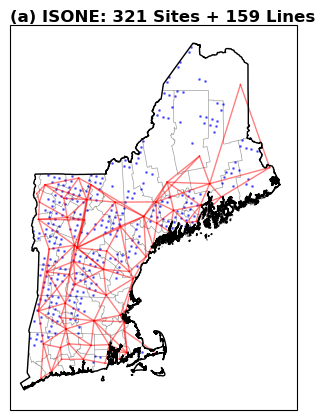

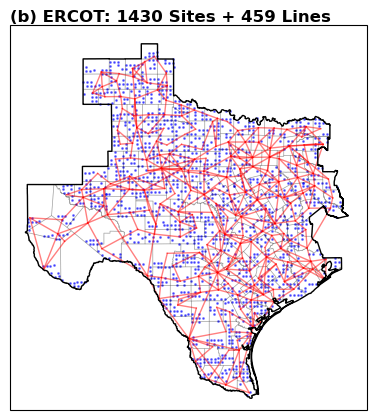

In [ ]:
for ij,ISO in enumerate(ISOs):
    node_info=pd.read_csv(f'preprocess/Network/Power_Nodes_{ISO}.csv',index_col='FIPS')
    fig,axs=plt.subplots(1,1,figsize=(5,5),subplot_kw={'projection': ccrs.PlateCarree()})
    counties = gpd.read_file(f'./ISO_county/{ISO}.shp')
    outline = counties.dissolve()
    util.setupmapbg(axs, ISO)
    counties.boundary.plot(
            ax=axs, color='black', linewidth=0.5, alpha=0.2)
    outline.boundary.plot(ax=axs, color='black', 
    linewidth=1.0,  alpha=1,zorder=5)

    df_output=pd.read_csv(f'preprocess/Network/Transmission_Lines_{ISO}_existing.csv')
    for index, row in df_output.iterrows():
        try:
            lon1 = row['from_lon']
            lat1 = row['from_lat']
            lon2 = row['to_lon']
            lat2 = row['to_lat']
            total_capacity = row['capacity']
            axs.plot([lon1, lon2], [lat1, lat2], color='red', linewidth=1, alpha=0.5)
        except:
            continue
    df_candidates=pd.read_csv(f'/orcd/nese/mhowland/001/lyqiu/GODEEP/NE_2025/preprocess/Resource/{ISO}/cf_wind/Loc_table.csv')
    df_canddidates=df_candidates.dropna(subset=['lat','lon'])
    axs.scatter(df_canddidates['lon'],df_canddidates['lat'],s=1,color='blue',alpha=0.5)
    util.setsubtitle(ax=axs,title=f'{ISO}: {len(df_canddidates)} Sites + {len(df_output)} Lines',ni=ij)
    plt.savefig(f'./figures/Network_{ISO}.pdf',dpi=300)

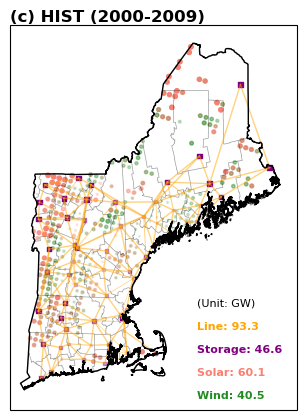

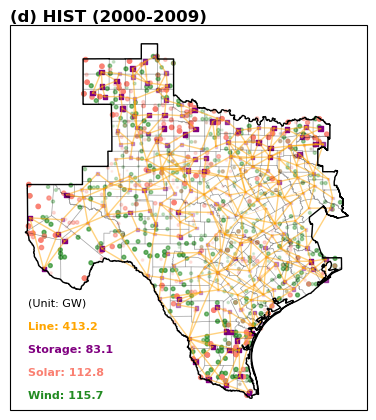

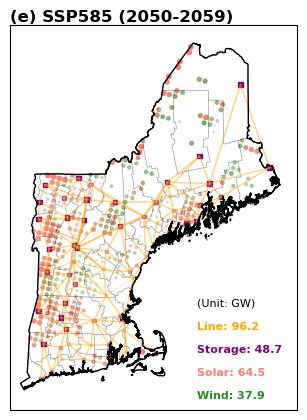

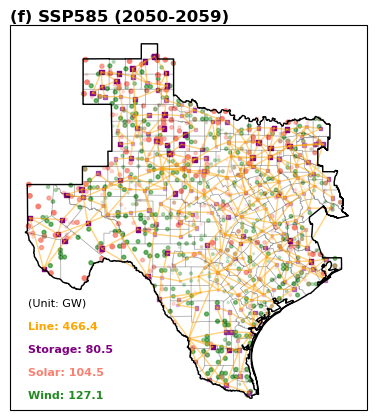

In [46]:
smin=0
smax=10
vmin=0
vmax=700

xtexts={'ISONE':0.65,'ERCOT':0.05}
sces=['historic','rcp85hotter']
cap_tech_name={'wind-onshore':'Total_capacity','solar-UPV':'Total_capacity',
        'CCGT':'Total_CCGT','strg':'Total_storage_capacity'}
cap_shape={'wind-onshore':'o','solar-UPV':'o',
        'CCGT':'^','strg':'s'}

ik=0
for ic, sce in enumerate(sces):
    for ISO in ISOs:
        counties = gpd.read_file(f'./ISO_county/{ISO}.shp')
        outline = counties.dissolve()
        countylist = pd.read_csv(f"./preprocess/Network/{ISO}_county_list.csv",
        dtype={'FIPS': int})
    
        fig,axs=plt.subplots(1,1,figsize=(5,5),subplot_kw={'projection': ccrs.PlateCarree()})
        util.setupmapbg(axs, ISO)
        counties.boundary.plot(ax=axs, color='black', linewidth=0.5, alpha=0.2)
        outline.boundary.plot(ax=axs, color='black', linewidth=1.0,  alpha=1,zorder=5)
        iv=0
        for tech in ['wind-onshore','solar-UPV','strg']:
            if tech in techs_RE:
                cap_df = pd.read_csv(f"{mdir}/result_{ISO}_inv/RPS_1_ny_2_{sce}_{tech}_capacity_grouped.csv").dropna()
            else:
                cap_df = pd.read_csv(f"{mdir}/result_{ISO}_inv/RPS_1_ny_2_{sce}_nodal_capacity_grouped.csv").dropna()
                cap_df=pd.merge(cap_df,countylist[['FIPS','lon','lat']],left_index=True,right_index=True)

            sumcap = cap_df[cap_tech_name[tech]].sum()
            if sumcap>0:
                axs.text(xtexts[ISO], 0.03+iv*0.06, f"{tech_names[tech]}: {sumcap/1000:.1f}", fontsize=8, 
                transform=axs.transAxes,color=colorpalattes[tech],fontweight='bold')

                s_scaled = scale_sizes(
                    cap_df[cap_tech_name[tech]],
                    smin=smin, smax=smax, transform="sqrt",
                    vmin=vmin, vmax=vmax
                )
                alphas=scale_sizes(
                    cap_df[cap_tech_name[tech]],
                    smin=0.1, smax=1,  # Minimum alpha 0.2 so points don't disappear
                    transform="linear",   # Usually linear is better for alpha than sqrt
                    vmin=vmin, vmax=vmax
                )
                rgba_colors = [to_rgba(colorpalattes[tech], alpha=a) for a in alphas]
                axs.scatter(cap_df['lon'], cap_df['lat'], s=s_scaled, color=rgba_colors, label=tech,marker=cap_shape[tech])
                iv+=1
        
        linecapacity=pd.read_csv(f"{mdir}/result_{ISO}_inv/RPS_1_ny_2_{sce}_line_capacity_grouped.csv").dropna()
        for index, row in linecapacity.iterrows():
            lon1 = row['from_lon']
            lat1 = row['from_lat']
            lon2 = row['to_lon']
            lat2 = row['to_lat']
            total_capacity = row['Total_capacity']
            w_total=scale_sizes(total_capacity,smin=0,smax=1,transform="sqrt",vmin=0,vmax=30)
            axs.plot([lon1, lon2], [lat1, lat2], color='orange', linewidth=w_total, alpha=0.5)
        sumcap= linecapacity['Total_capacity'].sum()
        axs.text(xtexts[ISO], 0.03+iv*0.06, f"Line: {sumcap/1000:.1f}", fontsize=8, transform=axs.transAxes,color='orange',fontweight='bold')
        iv+=1
        
        axs.text(xtexts[ISO], 0.03+iv*0.06, f"(Unit: GW)", fontsize=8, transform=axs.transAxes)
        if sce=='historic':
            util.setsubtitle(axs, f"HIST (2000-2009)", ni=ik+2)
        else:
            util.setsubtitle(axs, f"SSP585 (2050-2059)", ni=ik+2)
        plt.savefig(f'figures/capacity_map_{ISO}_{sce}.pdf',bbox_inches='tight',dpi=300)
        plt.show()
        ik+=1
